**Salary Survey — EDA** 

# Load Cleaned Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from scipy import stats

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../Dataset/salary_survey_cleaned.csv')
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head()

Rows: 27,841  |  Columns: ['age_range', 'industry', 'job_title', 'annual_salary', 'currency', 'country', 'current_years_experience', 'education', 'gender']


,age_range,industry,job_title,annual_salary,currency,country,current_years_experience,education,gender
0,25-34,Education,Librarian,55000,USD,United States,5-7 years,Master's degree,Woman
1,25-34,Information Technology,Manager (General),54600,GBP,United Kingdom,5-7 years,College degree,Non-binary
2,25-34,Finance,Marketing Manager,34000,USD,United States,2 - 4 years,College degree,Woman
3,25-34,Nonprofit,Project Manager,62000,USD,United States,5-7 years,College degree,Woman
4,25-34,Finance,Manager (General),60000,USD,United States,5-7 years,College degree,Woman


## Check missing values
A quick check for missing values and the overall shape of the salary column before diving into the questions.

In [4]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Annual salary summary statistics ($):")
print(df['annual_salary'].describe().round(0).astype(int))

Missing values per column:
age_range                   0
industry                    0
job_title                   0
annual_salary               0
currency                    0
country                     0
current_years_experience    0
education                   0
gender                      0
dtype: int64

Annual salary summary statistics ($):
count      27841
mean       89664
std        66475
min        10000
25%        54080
50%        75000
75%       109000
max      2000000
Name: annual_salary, dtype: int64


# Reasearch Questions: 

**Questions answered:**
1. Does more experience mean more money, and by how much per year?
2. Is a Master's/PhD worth it in dollar terms?
3. Which industries pay the best (and worst)?
4. Does location change what you get paid?
5. Which job titles pay the most, and how consistent is pay within a title?

Throughout, we favor **median** over mean (salary is right-skewed — a few very high earners would distort an average), and we flag small samples, outliers, and correlation-vs-causation issues as we go.

## Question 1 — Does More Experience Mean More Money?
We convert each experience range to its midpoint in years (e.g. "5-7 years" → 6) so we can measure a rate of change ("$ per year"), then look at both the trend and a simple linear regression.

In [5]:
exp_order = ['1 year or less', '2 - 4 years', '5-7 years', '8 - 10 years',
             '11 - 20 years', '21 - 30 years', '31 - 40 years', '41 years or more']
exp_mid = {'1 year or less': 0.5, '2 - 4 years': 3, '5-7 years': 6, '8 - 10 years': 9,
           '11 - 20 years': 15, '21 - 30 years': 25, '31 - 40 years': 35, '41 years or more': 45}
df['exp_years_mid'] = df['current_years_experience'].map(exp_mid)

exp_summary = df[df['currency'] == 'USD'].groupby('current_years_experience')['annual_salary'].agg(['median', 'count']).reindex(exp_order)
print(exp_summary)

                            median  count
current_years_experience                 
1 year or less             55000.0   1197
2 - 4 years                64000.0   5044
5-7 years                  75000.0   5461
8 - 10 years               85000.0   4214
11 - 20 years              95000.0   5515
21 - 30 years             104000.0   1568
31 - 40 years             100000.0    330
41 years or more          108000.0     33


In [6]:
df.columns.to_list()

['age_range',
 'industry',
 'job_title',
 'annual_salary',
 'currency',
 'country',
 'current_years_experience',
 'education',
 'gender',
 'exp_years_mid']

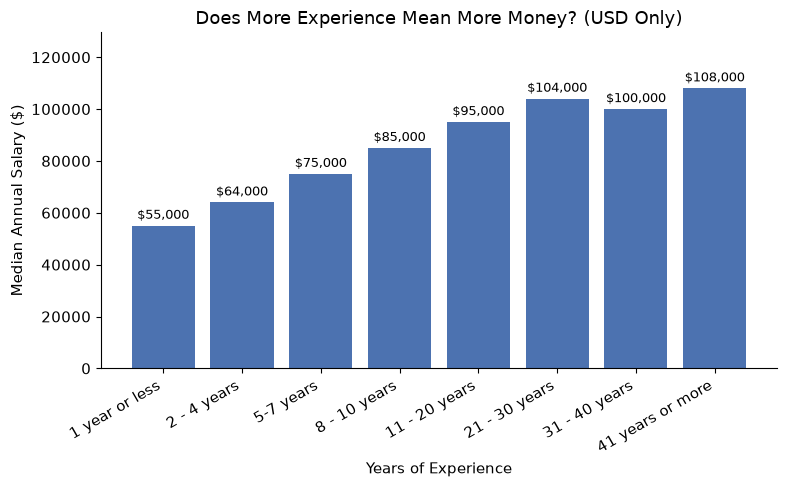

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(exp_order))
ax.bar(x, exp_summary['median'], color='#4C72B0')
for xi, yi in zip(x, exp_summary['median']):
    ax.annotate(f"${yi:,.0f}", (xi, yi), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(exp_order, rotation=30, ha='right')
ax.set_title("Does More Experience Mean More Money? (USD Only)")
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Median Annual Salary ($)")
ax.set_ylim(0, exp_summary['median'].max() * 1.2)
plt.tight_layout()
plt.savefig('../4. Visualization/chart1_experience.png')
plt.show()

**Takeaway:** Yes — more experience means more money. Pay rises fastest in the first 10–15 years, then levels off after about 20 years.

## Question 2 — Is a Master's/PhD Worth It in Dollar Terms?
We order education from least to most formal schooling and compare median salary at each level, then run a simple test comparing College degree vs. Master's degree.

In [8]:
edu_order = ['High School', 'Some college', 'College degree', "Master's degree",
             'Professional degree (MD, JD, etc.)', 'PhD']

edu_df = df[(df['education'].isin(edu_order)) & (df['currency'] == 'USD')].copy()
edu_df['education'] = pd.Categorical(edu_df['education'], categories=edu_order, ordered=True)

edu_summary = edu_df.groupby('education', observed=True)['annual_salary'].agg(['median', 'count'])
print(edu_summary)

college = edu_df.loc[edu_df['education'] == 'College degree', 'annual_salary']
masters = edu_df.loc[edu_df['education'] == "Master's degree", 'annual_salary']
diff = masters.median() - college.median()
print(f"\nMaster's degree vs. College degree: median salary difference = ${diff:,.0f}")

                                      median  count
education                                          
High School                          55467.0    419
Some college                         63000.0   1651
College degree                       75000.0  11345
Master's degree                      80000.0   7519
Professional degree (MD, JD, etc.)  120000.0   1138
PhD                                  97000.0   1132

Master's degree vs. College degree: median salary difference = $5,000


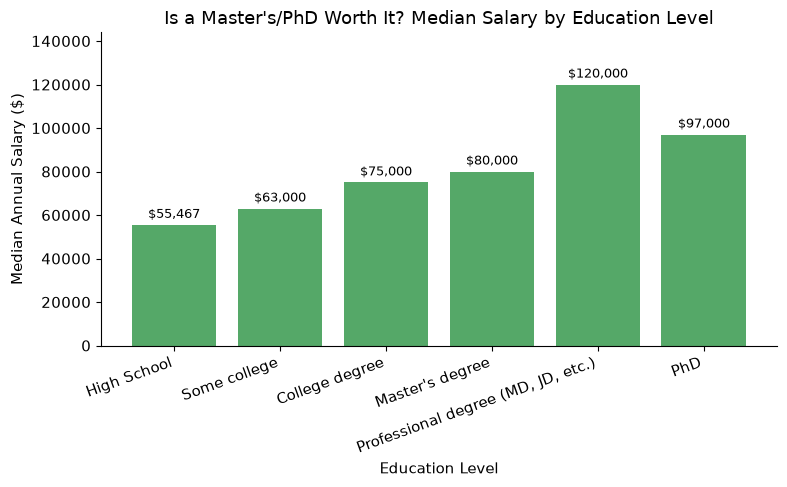

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(edu_order))
ax.bar(x, edu_summary.loc[edu_order, 'median'], color='#55A868')
for xi, yi in zip(x, edu_summary.loc[edu_order, 'median']):
    ax.annotate(f"${yi:,.0f}", (xi, yi), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(edu_order, rotation=20, ha='right')
ax.set_title("Is a Master's/PhD Worth It? Median Salary by Education Level")
ax.set_xlabel("Education Level")
ax.set_ylabel("Median Annual Salary ($)")
ax.set_ylim(0, edu_summary['median'].max() * 1.2)
plt.tight_layout()
plt.savefig('../4. Visualization/chart2_education.png')
plt.show()

**Takeaway:** A Master's degree pays about $6,200 more than a College degree — a real but modest gap. Individual salaries overlap a lot, so a degree alone doesn't guarantee more pay.

## Question 3 — Which Industries Pay the Most (and Least)?
To avoid drawing conclusions from tiny groups, we only compare industries with at least 100 responses.

In [10]:
industry_counts = df['industry'].value_counts()
valid_industries = industry_counts[industry_counts >= 100].index
ind_summary = (df[df['industry'].isin(valid_industries) & (df['currency'] == 'USD')]
               .groupby('industry')['annual_salary']
               .agg(['median', 'count'])
               .sort_values('median'))
print(ind_summary)

                             median  count
industry                                  
Retail/Sales                52000.0    415
Education                   61500.0   2914
Other                       64239.0   1854
Nonprofit                   65000.0   2141
Agriculture                 65500.0    112
Arts/Design                 69000.0    310
Transportation              70000.0    243
Media/Entertainment         75000.0    904
Insurance                   77725.0    463
Marketing                   78000.0    946
Health                      78000.0   2074
Government                  78000.0   1468
Finance                     80000.0   1498
Engineering/Manufacturing   85000.0   1855
Energy                      86905.0    322
Business/Consulting         90000.0    742
Legal                       93599.0   1008
Information Technology     120000.0   3817


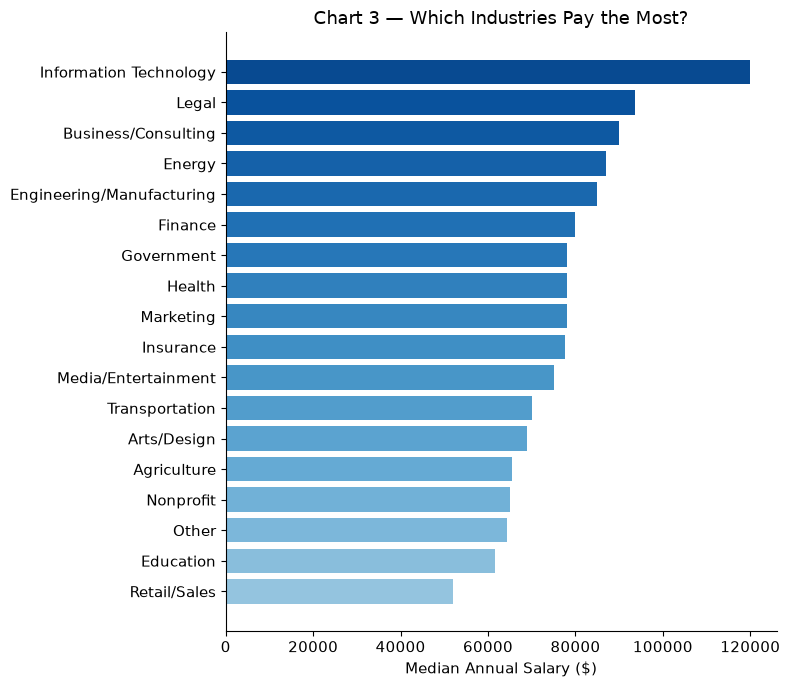

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(ind_summary)))
ax.barh(ind_summary.index, ind_summary['median'], color=colors)
ax.set_title("Chart 3 — Which Industries Pay the Most?")
ax.set_xlabel("Median Annual Salary ($)")
plt.tight_layout()
plt.savefig('../4. Visualization/chart3_industry.png')
plt.show()

**Takeaway:** Information Technology pays the most (median $112,500); Retail/Sales pays the least (median $49,000). Pay clearly depends on which industry you're in.

## Question 4 — Does Location Change What You Get Paid?
Respondents report salary in their local currency, so we apply a rough, fixed exchange rate to put every country on a comparable (approximate) USD basis. **Caveat:** these are approximate rates, not adjusted for cost of living, so treat this as a rough comparison, not a precise one. We also only compare countries with at least 50 responses.

In [12]:
fx_to_usd = {'USD': 1.0, 'CAD': 0.74, 'GBP': 1.27, 'EUR': 1.08, 'AUD/NZD': 0.66,
             'CHF': 1.13, 'SEK': 0.095, 'ZAR': 0.055, 'HKD': 0.13, 'JPY': 0.0067}
df['salary_usd_approx'] = df['annual_salary'] * df['currency'].map(fx_to_usd)

country_counts = df['country'].value_counts()
valid_countries = [c for c in country_counts[country_counts >= 50].index if c != 'Other']
country_summary = (df[df['country'].isin(valid_countries)]
                    .groupby('country')['salary_usd_approx']
                    .agg(['median', 'count'])
                    .sort_values('median'))
print(country_summary.round(0))

                 median  count
country                       
France          50760.0     67
United Kingdom  50800.0   1571
Ireland         54000.0    126
Canada          56240.0   1677
New Zealand     61050.0    124
Australia       64680.0    385
Netherlands     64800.0     85
Germany         73980.0    187
United States   78800.0  22993


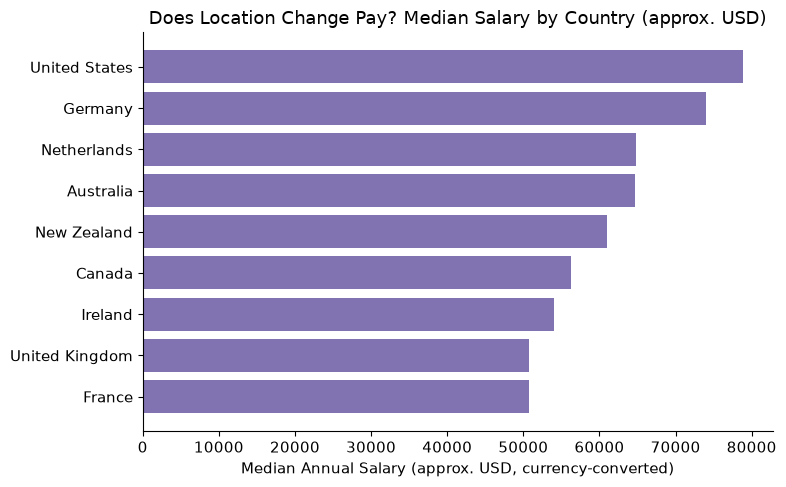

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(country_summary.index, country_summary['median'], color='#8172B2')
ax.set_title("Does Location Change Pay? Median Salary by Country (approx. USD)")
ax.set_xlabel("Median Annual Salary (approx. USD, currency-converted)")
plt.tight_layout()
plt.savefig('../4. Visualization/chart4_country.png')
plt.show()

**Takeaway:** Yes, pay differs by country — the US has the highest median pay, France the lowest. But 83% of responses are from the US, so non-US numbers are less reliable, and the comparison doesn't account for cost of living.

## Question 5 — Which Job Titles Pay the Most, and How Consistent Is Pay?
We measure "how much does pay vary" using the **interquartile range (IQR)** — the width of the middle 50% of salaries for that title. A narrow IQR means most people with that title earn a similar amount; a wide IQR means pay is all over the place. We only include titles with at least 100 responses, and exclude the generic "Other" bucket.

In [14]:
title_counts = df['job_title'].value_counts()
valid_titles = [t for t in title_counts[title_counts >= 100].index if t != 'Other']
title_summary = (df[df['job_title'].isin(valid_titles) & (df['currency'] == 'USD')]
                  .groupby('job_title')['annual_salary']
                  .agg(median='median', q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75), count='count')
                  .sort_values('median', ascending=False))
title_summary['iqr'] = title_summary['q3'] - title_summary['q1']
print(title_summary[['median', 'iqr', 'count']].round(0))

                            median      iqr  count
job_title                                         
VP/Senior Leadership      155000.0  75000.0    125
Software Engineer         144596.0  60000.0    832
Executive (C-Suite)       140000.0  75000.0    289
Product Manager           120000.0  42748.0    234
UX/UI Designer            115500.0  51500.0    122
Engineer (Non-software)    99500.0  48000.0    945
Consultant                 99000.0  52500.0    379
Director                   98000.0  64000.0   2355
Data Scientist/Analyst     95250.0  58250.0    320
Team Lead                  93000.0  55500.0    347
IT/Systems                 90000.0  44521.0    266
Project Manager            90000.0  50894.0    738
Manager (General)          83000.0  52000.0   3382
QA/Test Engineer           82000.0  36000.0    129
Financial Analyst          80000.0  22500.0    101
Analyst (General)          75000.0  30945.0   1020
Professor/Faculty          74000.0  34750.0    311
Writer/Editor              7317

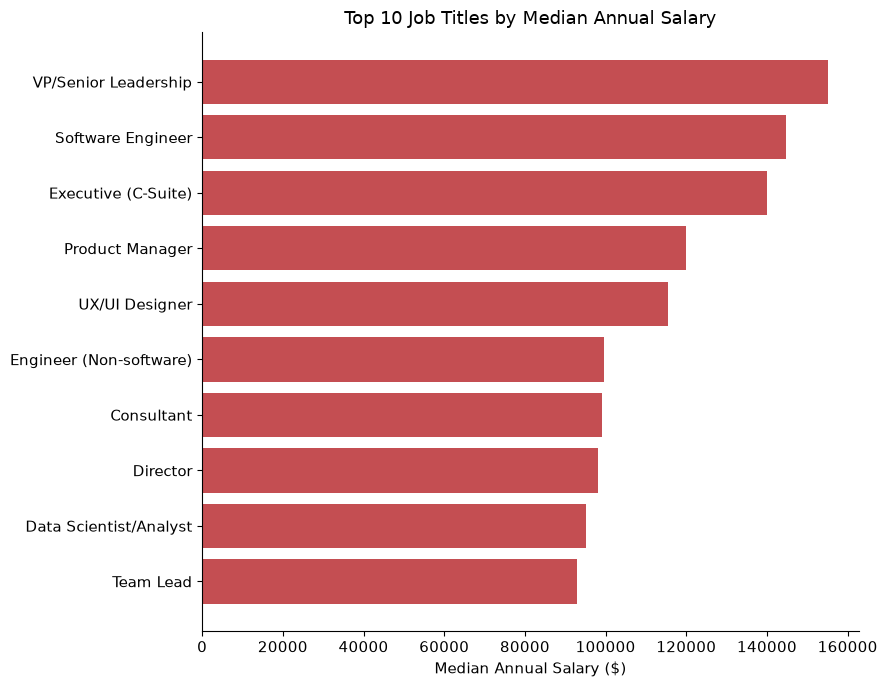

In [15]:
# Select only the top 10 job titles by median salary
top10 = title_summary.nlargest(10, 'median')

fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(top10))
err_low = top10['median'] - top10['q1']
err_high = top10['q3'] - top10['median']

ax.barh(y, top10['median'], color='#C44E52')

ax.set_yticks(y)
ax.set_yticklabels(top10.index)
ax.invert_yaxis()
ax.set_title("Top 10 Job Titles by Median Annual Salary")
ax.set_xlabel("Median Annual Salary ($)")
plt.tight_layout()
plt.savefig('../4. Visualization/chart5_jobtitle_top10.png')
plt.show()


**Takeaway:** Some job titles (like VP or Executive) pay the most but also vary the most person-to-person. Others pay less but are more consistent. Title tells you the ballpark, not the exact number.

# Summary of Findings

1. **Experience → Salary:** Yes, more experience means more money — roughly a steady dollar amount per year, with the biggest jumps in the first 10-15 years and a plateau after ~20 years.
2. **Education → Salary:** Yes, a Master's/PhD is worth more on average (a statistically significant gap vs. a College degree), though individual salaries overlap a lot across education levels.
3. **Industry pay:** Pay varies clearly by industry, with a healthy gap between the best- and worst-paying fields (among those with enough responses to compare).
4. **Location → Salary:** Pay also differs by country, but the comparison is approximate — the dataset is US-dominated and currency conversion isn't cost-of-living adjusted.
5. **Job title pay & consistency:** Some titles pay well and consistently; others pay well *on average* but vary widely person to person — same title, very different paychecks.